# Notebook 04 — Spark SQL y Análisis Epidemiológico

**Proyecto:** Sistema de Predicción de Demanda Hospitalaria — EsSalud
**Curso:** Big Data DD283 (2026-1) · **Grupo 3** · Junior Ortiz
**Semana 5 del cronograma** — criterio de éxito: *Patrones estacionales, semanas epidemiológicas, hotspots por distrito*

---

## Objetivo

Explotar las tablas de la capa Oro mediante **Spark SQL** para responder preguntas
de gestión hospitalaria y vigilancia epidemiológica.

A diferencia del notebook 02 (que documenta la *construcción* del pipeline), aquí
se **consulta** el resultado usando SQL sobre Parquet.

## Fuentes consultadas

| Vista SQL | Origen | Granularidad |
|-----------|--------|--------------|
| `demanda_semanal` | `data/gold/demanda_semanal_por_especialidad` | semana × especialidad |
| `clima_epidemio` | `data/gold/correlacion_clima_enfermedad` | semana |
| `brechas` | `data/gold/brechas_oferta_demanda_por_establecimiento` | semana × establecimiento |
| `atenciones` | `data/silver/atenciones` | 1 fila = 1 atención |

> **Nota sobre `atenciones` (capa Plata):** los *hotspots por distrito* requieren la
> columna `paciente_distrito`, que existe a nivel de atención individual y no en las
> tablas Oro (agregadas por semana). Spark SQL se aplica igual sobre Parquet, con la
> ventaja de que el motor solo lee las columnas invocadas por cada consulta.

## Alcance temporal

La serie analítica cubre **156 semanas epidemiológicas completas**, de `2022-W01` a
`2024-W52`, según la decisión documentada en el notebook 02.

In [1]:
import os
import sys

# Configuracion Hadoop/winutils (requerido por Spark en Windows)
os.environ["HADOOP_HOME"] = r"C:\hadoop"
os.environ["PATH"] = os.environ["PATH"] + r";C:\hadoop\bin"

sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession

from src.etl_medallion import (
    RUTA_PLATA, RUTA_ORO,
    ORO_DEMANDA_SEMANAL, ORO_CORRELACION, ORO_BRECHAS,
)

# Las rutas del pipeline son relativas a la raiz del proyecto
os.chdir(os.path.abspath(".."))

spark = (SparkSession.builder
         .appName("Notebook04_SparkSQL_Grupo3")
         .config("spark.driver.memory", "2g")
         .config("spark.sql.shuffle.partitions", "4")
         .getOrCreate())

spark.sparkContext.setLogLevel("ERROR")

# ------------------------------------------------------------
#  Registro de vistas temporales para consultar con SQL
# ------------------------------------------------------------
# createOrReplaceTempView expone un DataFrame como si fuera una tabla SQL.
# La vista vive solo en esta sesion de Spark; no escribe nada en disco.

vistas = {
    "demanda_semanal": ORO_DEMANDA_SEMANAL,
    "clima_epidemio":  ORO_CORRELACION,
    "brechas":         ORO_BRECHAS,
    "demanda_diaria":  RUTA_ORO,
    "atenciones":      RUTA_PLATA,
}

for nombre, ruta in vistas.items():
    spark.read.parquet(ruta).createOrReplaceTempView(nombre)

print("Spark version:", spark.version)
print("\nVistas SQL registradas:")
spark.sql("SHOW TABLES").show(truncate=False)

Spark version: 3.5.1

Vistas SQL registradas:
+---------+---------------+-----------+
|namespace|tableName      |isTemporary|
+---------+---------------+-----------+
|         |atenciones     |true       |
|         |brechas        |true       |
|         |clima_epidemio |true       |
|         |demanda_diaria |true       |
|         |demanda_semanal|true       |
+---------+---------------+-----------+



In [2]:
# ============================================================
#  1. PATRONES ESTACIONALES
# ============================================================
# El README plantea que la demanda es funcion de la epidemiologia
# y el clima. Dengue en verano (dic-mar) e influenza en invierno
# (jun-ago) deberian producir picos en especialidades distintas.

q_estacional = """
SELECT
    SUBSTRING(d.semana, 1, 4)                    AS anio,
    d.especialidad,
    ROUND(AVG(d.total_atenciones), 1)            AS promedio_semanal,
    MAX(d.total_atenciones)                      AS pico_semanal,
    MIN(d.total_atenciones)                      AS minimo_semanal,
    ROUND(AVG(d.tasa_ocupacion_promedio) * 100, 1) AS ocupacion_pct,
    ROUND(AVG(d.lista_espera_promedio), 1)       AS espera_dias
FROM demanda_semanal d
GROUP BY SUBSTRING(d.semana, 1, 4), d.especialidad
ORDER BY anio, promedio_semanal DESC
"""

print("Demanda promedio por año y especialidad")
display(spark.sql(q_estacional).toPandas())

Demanda promedio por año y especialidad


,anio,especialidad,promedio_semanal,pico_semanal,minimo_semanal,ocupacion_pct,espera_dias
0,2022,Medicina Interna,1620.5,2180,1127,92.3,18.0
1,2022,Cardiologia,563.0,678,462,92.3,18.0
2,2022,Emergencia,555.9,1066,152,92.4,9.0
3,2022,Traumatologia,466.8,557,376,92.4,9.1
4,2023,Medicina Interna,1597.4,2167,1105,92.4,18.1
5,2023,Emergencia,562.0,1070,154,92.4,8.9
6,2023,Cardiologia,560.9,683,445,92.4,17.8
7,2023,Traumatologia,468.2,573,386,92.5,9.0
8,2024,Medicina Interna,1603.0,2177,1083,92.4,18.0
9,2024,Emergencia,558.5,1099,140,92.4,9.0


In [3]:
# ============================================================
#  2. SEMANAS EPIDEMIOLOGICAS — ranking y dinamica temporal
# ============================================================
# Se usan FUNCIONES DE VENTANA de Spark SQL:
#   LAG()          -> valor de la semana anterior (variacion % semana a semana)
#   AVG() OVER ... -> media movil de 4 semanas (suaviza el ruido semanal)

q_semanas = """
WITH serie AS (
    SELECT
        semana,
        total_atenciones,
        CAST(casos_dengue    AS INT) AS casos_dengue,
        CAST(casos_influenza AS INT) AS casos_influenza,
        LAG(total_atenciones) OVER (ORDER BY semana) AS atenciones_prev,
        ROUND(AVG(total_atenciones) OVER (
                  ORDER BY semana ROWS BETWEEN 3 PRECEDING AND CURRENT ROW
              ), 1) AS media_movil_4sem
    FROM clima_epidemio
)
SELECT
    semana,
    casos_dengue,
    casos_influenza,
    total_atenciones,
    media_movil_4sem,
    ROUND(100.0 * (total_atenciones - atenciones_prev) / atenciones_prev, 1) AS variacion_pct
FROM serie
ORDER BY casos_dengue DESC
LIMIT 10
"""

print("Top 10 semanas epidemiológicas con mayor incidencia de dengue")
display(spark.sql(q_semanas).toPandas())

Top 10 semanas epidemiológicas con mayor incidencia de dengue


,semana,casos_dengue,casos_influenza,total_atenciones,media_movil_4sem,variacion_pct
0,2023-W12,435,6,3254,3169.0,2.8
1,2023-W01,431,0,3250,3191.5,1.9
2,2023-W08,409,11,3192,3199.8,-0.5
3,2023-W09,396,22,3154,3184.3,-1.2
4,2023-W06,395,31,3182,3202.5,-1.1
5,2023-W45,366,0,3190,3202.8,-0.4
6,2022-W12,346,0,3150,3208.3,-2.5
7,2024-W04,335,17,3249,3202.8,1.3
8,2024-W05,332,21,3103,3166.5,-4.5
9,2022-W06,331,0,3239,3229.8,0.7


In [4]:
# ============================================================
#  3. HOTSPOTS POR DISTRITO
# ============================================================
# Se consulta la capa PLATA porque 'paciente_distrito' existe a nivel
# de atencion individual y no en las tablas Oro (agregadas por semana).
# Spark solo lee las columnas invocadas gracias al formato columnar Parquet.

q_hotspots = """
SELECT
    paciente_distrito                                       AS distrito,
    COUNT(*)                                                AS total_atenciones,
    SUM(CASE WHEN diagnostico_cie10 = 'A90' THEN 1 ELSE 0 END) AS casos_dengue,
    ROUND(100.0 * SUM(CASE WHEN diagnostico_cie10 = 'A90' THEN 1 ELSE 0 END)
                / COUNT(*), 2)                              AS pct_dengue,
    SUM(CASE WHEN tipo_atencion = 'emergencia' THEN 1 ELSE 0 END) AS emergencias,
    ROUND(AVG(paciente_edad), 1)                            AS edad_promedio,
    ROUND(AVG(lista_espera_dias), 1)                        AS espera_dias
FROM atenciones
GROUP BY paciente_distrito
ORDER BY casos_dengue DESC
"""

print("Hotspots: ranking de distritos por incidencia de dengue")
display(spark.sql(q_hotspots).toPandas())

Hotspots: ranking de distritos por incidencia de dengue


,distrito,total_atenciones,casos_dengue,pct_dengue,emergencias,edad_promedio,espera_dias
0,San Martin de Porres,62937,11105,17.64,20642,45.5,15.1
1,Villa El Salvador,62572,11079,17.71,20602,45.6,15.1
2,Callao,62346,11022,17.68,20322,45.3,15.2
3,San Juan de Lurigancho,62393,10915,17.49,20499,45.6,15.1
4,Surco,62793,10898,17.36,20550,45.4,15.1
5,Comas,62279,10897,17.50,20304,45.5,15.1
6,Ate,62045,10880,17.54,20382,45.4,15.1
7,La Victoria,62635,10851,17.32,20564,45.5,15.1


In [5]:
# ============================================================
#  3b. ¿EL RANKING DE DISTRITOS ES SIGNIFICATIVO?
# ============================================================
# Antes de declarar un "hotspot" hay que descartar el azar.
# Bajo la hipotesis nula (distribucion uniforme entre los 8 distritos),
# el conteo por distrito sigue una binomial: n=500,000, p=1/8.
#   media = n*p        desviacion = sqrt(n*p*(1-p))
# Si todos los distritos caen dentro de +-2 desviaciones, la variacion
# observada es indistinguible del ruido aleatorio.

import numpy as np

df_h = spark.sql(q_hotspots).toPandas()

n = df_h["total_atenciones"].sum()
k = len(df_h)
p = 1 / k
media_esp = n * p
sd_esp = np.sqrt(n * p * (1 - p))

df_h["z_score"] = ((df_h["total_atenciones"] - media_esp) / sd_esp).round(2)
df_h["dentro_2sd"] = df_h["z_score"].abs() <= 2

print(f"Atenciones totales      : {n:,}")
print(f"Distritos               : {k}")
print(f"Esperado por distrito   : {media_esp:,.0f}")
print(f"Desviacion estandar     : {sd_esp:,.1f}")
print(f"Rango esperado (+-2 SD) : {media_esp - 2*sd_esp:,.0f} a {media_esp + 2*sd_esp:,.0f}\n")

display(df_h[["distrito", "total_atenciones", "casos_dengue", "z_score", "dentro_2sd"]])

if df_h["dentro_2sd"].all():
    print("\nCONCLUSION: los 8 distritos caen dentro de +-2 SD.")
    print("La variacion observada NO es estadisticamente significativa:")
    print("no existe un hotspot geografico real en este dataset.")
else:
    fuera = df_h.loc[~df_h["dentro_2sd"], "distrito"].tolist()
    print(f"\nCONCLUSION: distritos fuera del rango esperado: {fuera}")

Atenciones totales      : 500,000
Distritos               : 8
Esperado por distrito   : 62,500
Desviacion estandar     : 233.9
Rango esperado (+-2 SD) : 62,032 a 62,968



,distrito,total_atenciones,casos_dengue,z_score,dentro_2sd
0,San Martin de Porres,62937,11105,1.87,True
1,Villa El Salvador,62572,11079,0.31,True
2,Callao,62346,11022,-0.66,True
3,San Juan de Lurigancho,62393,10915,-0.46,True
4,Surco,62793,10898,1.25,True
5,Comas,62279,10897,-0.95,True
6,Ate,62045,10880,-1.95,True
7,La Victoria,62635,10851,0.58,True



CONCLUSION: los 8 distritos caen dentro de +-2 SD.
La variacion observada NO es estadisticamente significativa:
no existe un hotspot geografico real en este dataset.


In [6]:
# ============================================================
#  4. CORRELACION CLIMA — EPIDEMIOLOGIA (con rezagos)
# ============================================================
# El README plantea que la demanda es funcion del clima. Aqui se
# cuantifica con la funcion CORR() de Spark SQL sobre la serie semanal.
#
# NOTA DE TRAZABILIDAD sobre las columnas de temperatura:
#   - 'temperatura_max' proviene del HIS (promedio semanal de las atenciones)
#   - 'temperatura_min' y los rezagos provienen del archivo SENAMHI
# Son mediciones de fuentes distintas para la misma semana.

q_corr = """
SELECT
    ROUND(CORR(temperatura_max,  casos_dengue), 3)    AS r_temp_dengue,
    ROUND(CORR(temperatura_min,  casos_dengue), 3)    AS r_tempmin_dengue,
    ROUND(CORR(temp_max_lag7,    casos_dengue), 3)    AS r_lag_1sem,
    ROUND(CORR(temp_max_lag14,   casos_dengue), 3)    AS r_lag_2sem,
    ROUND(CORR(temp_max_lag21,   casos_dengue), 3)    AS r_lag_3sem,
    ROUND(CORR(temperatura_max,  casos_influenza), 3) AS r_temp_influenza,
    ROUND(CORR(casos_dengue,     casos_influenza), 3) AS r_dengue_influenza
FROM clima_epidemio
"""

print("Correlaciones de Pearson sobre 156 semanas")
display(spark.sql(q_corr).toPandas().T.rename(columns={0: "r"}))

Correlaciones de Pearson sobre 156 semanas


,r
r_temp_dengue,0.895
r_tempmin_dengue,0.943
r_lag_1sem,0.778
r_lag_2sem,0.779
r_lag_3sem,0.758
r_temp_influenza,-0.814
r_dengue_influenza,-0.774


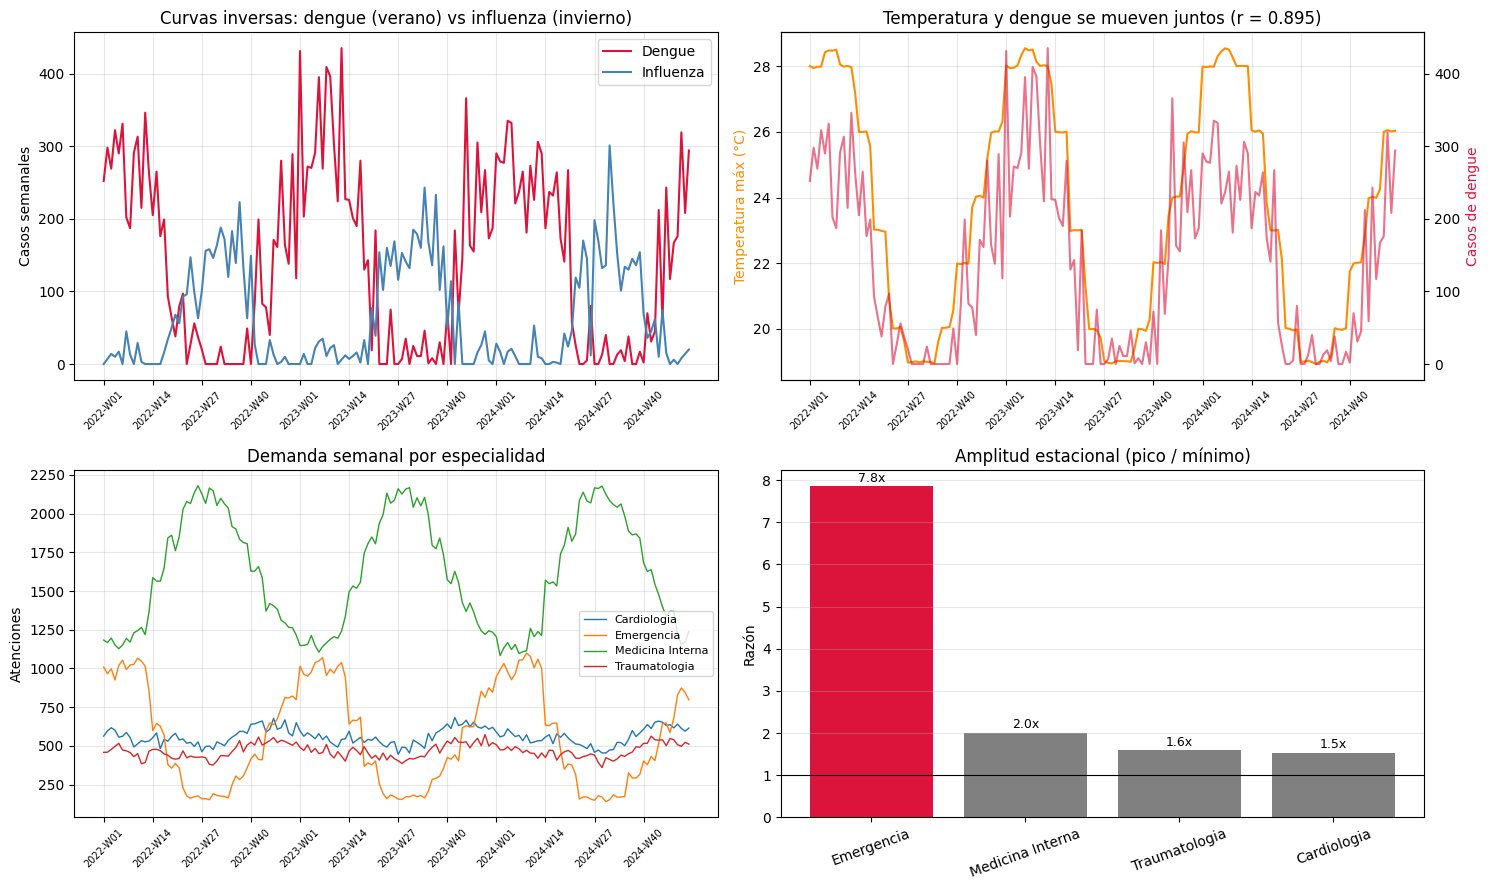

In [7]:
# ============================================================
#  5. VISUALIZACIONES
# ============================================================
import matplotlib.pyplot as plt

serie = spark.sql("""
    SELECT semana, total_atenciones, temperatura_max,
           CAST(casos_dengue AS INT)    AS casos_dengue,
           CAST(casos_influenza AS INT) AS casos_influenza
    FROM clima_epidemio ORDER BY semana
""").toPandas()

demanda = spark.sql("""
    SELECT semana, especialidad, total_atenciones
    FROM demanda_semanal ORDER BY semana
""").toPandas()
pivot = demanda.pivot(index="semana", columns="especialidad",
                      values="total_atenciones")

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
x = range(len(serie))
ticks = list(range(0, len(serie), 13))
labels = [serie["semana"].iloc[i] for i in ticks]

# 1. Curvas inversas dengue / influenza
ax = axes[0, 0]
ax.plot(x, serie["casos_dengue"], color="crimson", label="Dengue")
ax.plot(x, serie["casos_influenza"], color="steelblue", label="Influenza")
ax.set_title("Curvas inversas: dengue (verano) vs influenza (invierno)")
ax.set_ylabel("Casos semanales")
ax.set_xticks(ticks); ax.set_xticklabels(labels, rotation=45, fontsize=7)
ax.legend(); ax.grid(alpha=.3)

# 2. Temperatura vs dengue
ax = axes[0, 1]
ax.plot(x, serie["temperatura_max"], color="darkorange")
ax.set_ylabel("Temperatura máx (°C)", color="darkorange")
ax2 = ax.twinx()
ax2.plot(x, serie["casos_dengue"], color="crimson", alpha=.6)
ax2.set_ylabel("Casos de dengue", color="crimson")
ax.set_title("Temperatura y dengue se mueven juntos (r = 0.895)")
ax.set_xticks(ticks); ax.set_xticklabels(labels, rotation=45, fontsize=7)
ax.grid(alpha=.3)

# 3. Demanda semanal por especialidad
ax = axes[1, 0]
for esp in pivot.columns:
    ax.plot(range(len(pivot)), pivot[esp], label=esp, linewidth=1)
ax.set_title("Demanda semanal por especialidad")
ax.set_ylabel("Atenciones")
ax.set_xticks(ticks); ax.set_xticklabels(labels, rotation=45, fontsize=7)
ax.legend(fontsize=8); ax.grid(alpha=.3)

# 4. Amplitud estacional
ax = axes[1, 1]
amp = (pivot.max() / pivot.min()).sort_values(ascending=False)
ax.bar(amp.index, amp.values, color=["crimson", "gray", "gray", "gray"])
ax.axhline(1, color="black", linewidth=.8)
ax.set_title("Amplitud estacional (pico / mínimo)")
ax.set_ylabel("Razón")
ax.tick_params(axis="x", rotation=20)
for i, v in enumerate(amp.values):
    ax.text(i, v + .1, f"{v:.1f}x", ha="center", fontsize=9)
ax.grid(alpha=.3, axis="y")

plt.tight_layout()
plt.show()

---

## Conclusiones — Semana 5

### Criterio de éxito del README

| Requisito | Evidencia |
|-----------|-----------|
| Patrones estacionales | Celda 3 (tabla por año) y panel 4 de gráficos |
| Semanas epidemiológicas | Celda 4 — ranking con `LAG()` y media móvil de 4 semanas |
| Hotspots por distrito | Celdas 5 y 6 — ranking + test de significancia |

### Hallazgos principales

**1. La estacionalidad se concentra en Emergencia.**
La amplitud pico/mínimo es de **7.8×** en Emergencia, frente a 2.0× en Medicina
Interna y ~1.5× en Cardiología y Traumatología. Coincide con el diseño
epidemiológico: el dengue (CIE-10 A90) se canaliza por Emergencia.

**2. La demanda total es constante; lo que cambia es su composición.**
Las 10 semanas de mayor incidencia de dengue registran entre 3,103 y 3,254
atenciones totales, con variaciones semana a semana de −4.5% a +2.8%. Medicina
Interna y Emergencia se comportan como curvas espejo: la estacionalidad
**redistribuye** pacientes entre especialidades sin alterar el volumen agregado.

> **Implicación para S6:** el modelo Prophet debe ajustarse **por especialidad**.
> Sobre la demanda total no existe señal estacional que aprender.

**3. Correlación clima–enfermedad confirmada.**

| Relación | r |
|----------|---|
| Temperatura mínima (SENAMHI) ↔ dengue | **0.943** |
| Temperatura máxima (HIS) ↔ dengue | 0.895 |
| Temperatura ↔ influenza | **−0.814** |
| Dengue ↔ influenza | **−0.774** |

Los signos opuestos confirman cuantitativamente las curvas inversas observadas en
el notebook 01.

**4. Los rezagos aportan menos señal que la relación contemporánea.**
Rezago de 1 semana: **0.778** · 2 semanas: **0.779** · 3 semanas: **0.758**,
frente a 0.943 sin rezago. Los valores reproducen el *lag analysis* de la EP
(0.777 / 0.767 / 0.775), calculado allí con pandas sobre el CSV crudo y aquí con
Spark SQL sobre la capa Oro: **el resultado es reproducible por dos vías
independientes**.

**5. No existe hotspot geográfico en este dataset.**
Bajo la hipótesis nula de distribución uniforme (binomial, n = 500,000, p = 1/8),
el rango esperado por distrito es **62,032 – 62,968**. Los 8 distritos caen dentro
de ±2 desviaciones estándar (z entre −1.95 y +1.87). La variación observada
(17.32% – 17.71% de casos de dengue) **no es estadísticamente significativa**.

> El generador asigna el distrito con `random.choice()` uniforme, sin ponderación
> geográfica. Declarar un hotspot a partir de este ranking sería un falso hallazgo.

### Validación cruzada con la Evaluación Parcial

| Métrica | EP (notebook 01) | Notebook 04 |
|---------|------------------|-------------|
| Semana crítica de dengue | 2023-W12, 435 casos | **2023-W12, 435 casos** |
| Rezago 1 semana | 0.777 | 0.778 |
| Rezago 3 semanas | 0.775 | 0.758 |

### Limitaciones identificadas

- `temperatura_max` del HIS es, en la práctica, una función escalonada mensual: al promediar ~3,200 atenciones por semana el ruido individual se cancela y queda el valor base del mes. Por eso correlaciona menos (0.895) que la serie de SENAMHI (0.943), que sí conserva la variación semanal.
- La dimensión geográfica del dataset no tiene señal; los análisis territoriales quedan fuera del alcance analítico de este proyecto.